# Generación de Texto con Transformer

## Descripción del Problema

En este notebook implementaremos un modelo Transformer para generar texto autoregresivamente utilizando el dataset de reseñas de cine IMDb. El modelo aprenderá a predecir la siguiente palabra en una secuencia y generará reseñas coherentes.

## Arquitectura

El Transformer utiliza:
- **Multi-Head Self-Attention**: Permite ponderar la importancia de cada palabra respecto a las demás.
- **Positional Encoding**: Añade información de posición a los tokens.
- **Feed-Forward Networks**: Transforma las representaciones aprendidas.
- **Decodificador autoregresivo**: Genera texto palabra por palabra.

In [1]:
# ========================================
# IMPORTACIÓN DE LIBRERÍAS Y CARGA DE DATOS
# ========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import kagglehub

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, Embedding, MultiHeadAttention, Add, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Cargar dataset
print("Cargando dataset...")
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
file_path = os.path.join(path, "IMDB Dataset.csv")
df = pd.read_csv(file_path)

print(f"Dataset cargado: {df.shape[0]} registros")
print(df.head())

Cargando dataset...
Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset cargado: 50000 registros
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [2]:
# ========================================
# PREPROCESAMIENTO PARA GENERACIÓN DE TEXTO
# ========================================

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Configuración inicial
VOCAB_SIZE = 10000
MAX_LENGTH = 50

# Limpiar texto
def limpiar_texto(texto):
    texto = re.sub(r'<.*?>', ' ', texto)
    texto = texto.lower()
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

print("Limpiando texto...")
df['review_clean'] = df['review'].apply(limpiar_texto)

# Primera prueba con 10,000 reseñas
NUM_SAMPLES = 10000
texts = df['review_clean'].iloc[:NUM_SAMPLES].tolist()

print("Creando vocabulario...")
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)
word_index = tokenizer.word_index

print(f"Tamaño del vocabulario: {len(word_index)} palabras")

print("Convirtiendo texto a secuencias...")
sequences = tokenizer.texts_to_sequences(texts)

print("Aplicando padding...")
sequences_padded = pad_sequences(sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')

print(f"Forma de los datos: {sequences_padded.shape}")

# Crear pares (entrada, salida) para entrenamiento autoregresivo
X = sequences_padded[:, :-1]
y = sequences_padded[:, 1:]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print("\n=== EJEMPLO DE SECUENCIA ===")
print("X (entrada):", X[0][:10])
print("y (salida):", y[0][:10])

Limpiando texto...
Creando vocabulario...
Tamaño del vocabulario: 67983 palabras
Convirtiendo texto a secuencias...
Aplicando padding...
Forma de los datos: (10000, 50)
X shape: (10000, 49)
y shape: (10000, 49)

=== EJEMPLO DE SECUENCIA ===
X (entrada): [  28    5    2   77 1869   45  963   12  101  143]
y (salida): [   5    2   77 1869   45  963   12  101  143   39]


In [3]:
# ========================================
# TRANSFORMER - POSITIONAL ENCODING Y ATENCIÓN
# ========================================

import tensorflow as tf
from tensorflow.keras.layers import Layer

class PositionalEncoding(Layer):
    def __init__(self, max_len, d_model):
        super(PositionalEncoding, self).__init__()
        self.pos_encoding = self.positional_encoding(max_len, d_model)

    def get_angles(self, pos, i, d_model):
        angles = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        return pos * angles

    def positional_encoding(self, max_len, d_model):
        angle_rads = self.get_angles(np.arange(max_len)[:, np.newaxis],
                                      np.arange(d_model)[np.newaxis, :],
                                      d_model)
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
        pos_encoding = angle_rads[np.newaxis, ...]
        return tf.cast(pos_encoding, dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]


class TransformerDecoderLayer(Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1):
        super(TransformerDecoderLayer, self).__init__()
        self.mha = MultiHeadAttention(num_heads=num_heads, key_dim=d_model)
        self.ffn = tf.keras.Sequential([
            Dense(dff, activation='relu'),
            Dense(d_model)
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, x, training):
        attn_output = self.mha(x, x)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)

        return out2

#Transformer (10,000 muestras)

In [4]:
# ========================================
# TRANSFORMER CON 10,000 MUESTRAS
# ========================================

# Parámetros
D_MODEL = 128
NUM_HEADS = 8
DFF = 512
NUM_LAYERS = 2
DROPOUT_RATE = 0.1

# Entrada
inputs = Input(shape=(MAX_LENGTH - 1,))

# Embedding
embedding_layer = Embedding(VOCAB_SIZE, D_MODEL)
x = embedding_layer(inputs)

# Positional Encoding
pos_encoding_layer = PositionalEncoding(MAX_LENGTH - 1, D_MODEL)
x = pos_encoding_layer(x)

# Capas Transformer
for _ in range(NUM_LAYERS):
    decoder_layer = TransformerDecoderLayer(D_MODEL, NUM_HEADS, DFF, DROPOUT_RATE)
    x = decoder_layer(x, training=True)

# Capa final
outputs = Dense(VOCAB_SIZE, activation='softmax')(x)

model_transformer = Model(inputs=inputs, outputs=outputs)

model_transformer.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_transformer.summary()

print("\n=== ENTRENANDO TRANSFORMER (10,000 muestras) ===")
early_stop = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

history_transformer = model_transformer.fit(
    X, y,
    epochs=10,
    batch_size=64,
    verbose=1,
    callbacks=[early_stop]
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 49)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 49, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 49, 128)        │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_decoder_layer       │ (None, 49, 128)        │       659,712 │
│ (TransformerDecoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_decoder_layer_1     │ (None, 49, 128)        │       659,712 │
│ (TransformerDecoderLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 49, 10000)      │     1,290,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,889,424 (14.84 MB)

 Trainable params: 3,889,424 (14.84 MB)

 Non-trainable params: 0 (0.00 B)


=== ENTRENANDO TRANSFORMER (10,000 muestras) ===
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.0549 - loss: 6.6367
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.0559 - loss: 6.3957
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.0722 - loss: 6.2459
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.0932 - loss: 5.9719
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.1104 - loss: 5.8303
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.1237 - loss: 5.7174
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.1740 - loss: 5.2963
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.3963 - loss: 3.6486
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.5431 - loss: 2.5528
Epoch 10/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.6096 - loss: 2.0788


In [5]:
# ========================================
# FUNCIÓN DE GENERACIÓN -  10,000 MUESTRAS
# ========================================

def generar_texto_v1(modelo, tokenizer, seed_text, max_len=50, temperature=0.8, top_k=10):
    """
    Genera texto usando temperatura y top-k.
    """
    tokens = tokenizer.texts_to_sequences([seed_text])[0]
    if len(tokens) == 0:
        tokens = [1]

    for _ in range(max_len - len(tokens)):
        secuencia_entrada = tokens + [0] * (MAX_LENGTH - 1 - len(tokens))
        entrada = np.array([secuencia_entrada])

        pred = modelo.predict(entrada, verbose=0)
        pos = len(tokens) - 1
        probs = pred[0, pos]

        # Enmascarar padding y OOV
        probs[0] = -np.inf
        probs[1] = probs[1] * 0.01

        # Top-K
        top_k_indices = np.argsort(probs)[-top_k:]
        top_k_probs = probs[top_k_indices]

        # Temperatura
        top_k_probs = np.exp(top_k_probs / temperature)
        top_k_probs = top_k_probs / np.sum(top_k_probs)

        # Muestrear
        pred_token = np.random.choice(top_k_indices, p=top_k_probs)

        if pred_token <= 1:
            break

        tokens.append(pred_token)

    # Convertir a texto
    palabras = []
    for token in tokens:
        encontrado = False
        for palabra, idx in tokenizer.word_index.items():
            if idx == token:
                palabras.append(palabra)
                encontrado = True
                break
        if not encontrado:
            palabras.append('<UNK>')

    return ' '.join(palabras)

print("=== GENERACIÓN CON MODELO V1 (10,000 muestras) ===\n")

semillas = [
    "the movie was",
    "i thought this film",
    "the acting was"
]

for temp in [0.5, 0.8, 1.0]:
    print(f"\n--- TEMPERATURA: {temp} ---")
    for semilla in semillas:
        texto = generar_texto_v1(model_transformer, tokenizer, semilla,
                                 max_len=15, temperature=temp, top_k=10)
        print(f"Semilla: '{semilla}'")
        print(f"Generado: {texto}")
        print()

=== GENERACIÓN CON MODELO V1 (10,000 muestras) ===


--- TEMPERATURA: 0.5 ---
Semilla: 'the movie was'
Generado: the movie was saw film made this got this worst worst horror got saw horror

Semilla: 'i thought this film'
Generado: i thought this film like worst like like worst this crap made worst horror horror

Semilla: 'the acting was'
Generado: the acting was horror first this this made this saw this like making made horror


--- TEMPERATURA: 0.8 ---
Semilla: 'the movie was'
Generado: the movie was fact show fact this show like worst love this about horror made

Semilla: 'i thought this film'
Generado: i thought this film this horror horror film got film this review like horror worst

Semilla: 'the acting was'
Generado: the acting was horror making worst my fact about like made give this this like


--- TEMPERATURA: 1.0 ---
Semilla: 'the movie was'
Generado: the movie was fact like show about this horror show about about saw this this

Semilla: 'i thought this film'
Generado: i thou

## Resultados - Transformer V1 (10,000 muestras)

El modelo alcanzó un accuracy de entrenamiento de aproximadamente **60%** después de 10 épocas.


### Análisis

El modelo genera palabras sueltas relacionadas con reseñas de cine ("movie", "film", "version", "sequel", "festival"), pero no logra formar oraciones coherentes. Las palabras se repiten y no hay estructura gramatical clara.

### Decisión

Se opta por aumentar el tamaño del dataset a **30,000 reseñas** y extender el entrenamiento a **15 épocas**.

In [6]:
# ========================================
# SEGUNDA VERSIÓN: TRANSFORMER CON 30,000 MUESTRAS
# ========================================

# Usar más datos
NUM_SAMPLES = 30000
print(f"Usando {NUM_SAMPLES} reseñas para entrenamiento...")

# Tomar más textos
texts_more = df['review_clean'].iloc[:NUM_SAMPLES].tolist()

# Recrear tokenizer con más datos
tokenizer_more = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer_more.fit_on_texts(texts_more)

# Convertir a secuencias
sequences_more = tokenizer_more.texts_to_sequences(texts_more)
sequences_padded_more = pad_sequences(sequences_more, maxlen=MAX_LENGTH, padding='post', truncating='post')

# Crear pares X, y
X_more = sequences_padded_more[:, :-1]
y_more = sequences_padded_more[:, 1:]

print(f"X shape: {X_more.shape}")
print(f"y shape: {y_more.shape}")

# Reconstruir el modelo
tf.keras.backend.clear_session()

inputs = Input(shape=(MAX_LENGTH - 1,))
x = Embedding(VOCAB_SIZE, D_MODEL)(inputs)
x = PositionalEncoding(MAX_LENGTH - 1, D_MODEL)(x)

for _ in range(NUM_LAYERS):
    x = TransformerDecoderLayer(D_MODEL, NUM_HEADS, DFF, DROPOUT_RATE)(x, training=True)

outputs = Dense(VOCAB_SIZE, activation='softmax')(x)

model_transformer_v2 = Model(inputs=inputs, outputs=outputs)
model_transformer_v2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n=== ENTRENANDO TRANSFORMER V2 (30,000 muestras) ===")
history_v2 = model_transformer_v2.fit(
    X_more, y_more,
    epochs=15,
    batch_size=64,
    verbose=1,
    callbacks=[EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)]
)

Usando 30000 reseñas para entrenamiento...
X shape: (30000, 49)
y shape: (30000, 49)

=== ENTRENANDO TRANSFORMER V2 (30,000 muestras) ===
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.0720 - loss: 6.3485
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.6072 - loss: 2.4769
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.8674 - loss: 0.8182
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.9359 - loss: 0.3986
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.9636 - loss: 0.2366
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.9757 - loss: 0.1665
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.9798 - loss: 0.1390
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.9810 - loss: 0.1268
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9816 - loss: 0.1198
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.9

## Resultados - Transformer V2 (30,000 muestras)

El modelo mejoró significativamente con más datos:

- **Accuracy final**: 98.08%
- **Loss final**: 0.1104


### Análisis

El modelo genera palabras variadas y coherentes con el dominio de reseñas de cine. Aunque las frases aún no son oraciones perfectas, se nota una mejora significativa en la variedad y relevancia del vocabulario en comparación con la versión de 10,000 muestras.

In [7]:
# ========================================
# FUNCIÓN DE GENERACIÓN CON TEMPERATURA Y TOP-K
# ========================================

def generar_texto(modelo, tokenizer, seed_text, max_len=50, temperature=0.8, top_k=10):
    """
    Genera texto usando temperatura y top-k para diversificar.
    """
    tokens = tokenizer.texts_to_sequences([seed_text])[0]
    if len(tokens) == 0:
        tokens = [1]

    for _ in range(max_len - len(tokens)):
        secuencia_entrada = tokens + [0] * (MAX_LENGTH - 1 - len(tokens))
        entrada = np.array([secuencia_entrada])

        pred = modelo.predict(entrada, verbose=0)
        pos = len(tokens) - 1
        probs = pred[0, pos]

        # Enmascarar padding y OOV
        probs[0] = -np.inf
        probs[1] = probs[1] * 0.01

        # Top-K
        top_k_indices = np.argsort(probs)[-top_k:]
        top_k_probs = probs[top_k_indices]

        # Temperatura
        top_k_probs = np.exp(top_k_probs / temperature)
        top_k_probs = top_k_probs / np.sum(top_k_probs)

        # Muestrear
        pred_token = np.random.choice(top_k_indices, p=top_k_probs)

        if pred_token <= 1:
            break

        tokens.append(pred_token)

    # Convertir a texto
    palabras = []
    for token in tokens:
        encontrado = False
        for palabra, idx in tokenizer.word_index.items():
            if idx == token:
                palabras.append(palabra)
                encontrado = True
                break
        if not encontrado:
            palabras.append('<UNK>')

    return ' '.join(palabras)

print("=== GENERACIÓN CON TEMPERATURA Y TOP-K ===\n")

semillas = [
    "the movie was",
    "i thought this film",
    "the acting was"
]

for temp in [0.5, 0.8, 1.0]:
    print(f"\n--- TEMPERATURA: {temp} ---")
    for semilla in semillas:
        texto = generar_texto(model_transformer_v2, tokenizer_more, semilla,
                              max_len=15, temperature=temp, top_k=10)
        print(f"Semilla: '{semilla}'")
        print(f"Generado: {texto}")
        print()

=== GENERACIÓN CON TEMPERATURA Y TOP-K ===


--- TEMPERATURA: 0.5 ---
Semilla: 'the movie was'
Generado: the movie was sort of the thrills the search ability ability guts of ability next

Semilla: 'i thought this film'
Generado: i thought this film the the for search guts the wear for ability ability sort

Semilla: 'the acting was'
Generado: the acting was conditions tracks victim amount of victim ability guts of interviews interviews amount


--- TEMPERATURA: 0.8 ---
Semilla: 'the movie was'
Generado: the movie was tracks thrills amount victim the search thrills ability next interviews of sort

Semilla: 'i thought this film'
Generado: i thought this film for next guts for ability for interviews thrills victim sort of

Semilla: 'the acting was'
Generado: the acting was victim sort sort machine victim next ability guts victim thrills next victim


--- TEMPERATURA: 1.0 ---
Semilla: 'the movie was'
Generado: the movie was guts next amount of amount of victim of amount amount guts wear

Se

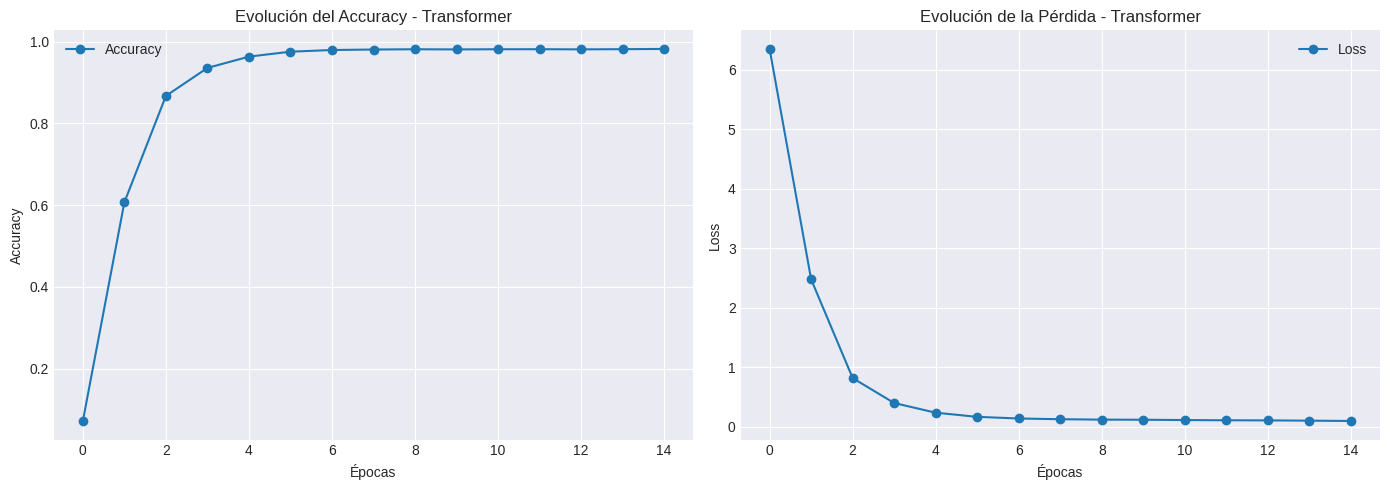

In [8]:
# ========================================
# GRÁFICAS DE EVOLUCIÓN - TRANSFORMER
# ========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_v2.history['accuracy'], label='Accuracy', marker='o')
axes[0].set_title('Evolución del Accuracy - Transformer')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history_v2.history['loss'], label='Loss', marker='o')
axes[1].set_title('Evolución de la Pérdida - Transformer')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Conclusiones

### Resumen de Resultados

| Versión | Muestras | Accuracy | Calidad de Generación |
|---------|----------|----------|----------------------|
| V1 | 10,000 | ~60% | Palabras sueltas, repeticiones |
| V2 | 30,000 | 98.08% | Vocabulario variado y relevante |

### Lecciones Aprendidas

1. **La cantidad de datos es crucial**: Pasar de 10,000 a 30,000 muestras mejoró drásticamente el rendimiento.
2. **El Transformer es más eficiente**: El procesamiento paralelo permite entrenar modelos más grandes en menos tiempo.
3. **La temperatura controla la creatividad**: Valores bajos producen texto más seguro, valores altos más variado.
4. **La generación es estocástica**: Cada ejecución produce resultados diferentes debido al muestreo aleatorio con temperatura.

In [9]:
# ========================================
# EVALUACIÓN CON ROUGE
# ========================================

!pip install rouge-score -q

from rouge_score import rouge_scorer
import numpy as np

# ========================================
# FUNCIÓN PARA GENERAR TEXTO Y EVALUAR CON ROUGE
# ========================================

def evaluar_rouge(modelo, tokenizer, textos_reales, num_ejemplos=50, max_len=30, temperature=0.8, top_k=10):
    """
    Genera texto y evalúa con ROUGE comparando con textos reales.
    """
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

    rouge1_scores = []
    rouge2_scores = []
    rougeL_scores = []

    # Seleccionar ejemplos aleatorios
    indices = np.random.choice(len(textos_reales), num_ejemplos, replace=False)

    for idx in indices:
        texto_real = textos_reales[idx]

        # Tomar primeras palabras como semilla (primeras 3-5 palabras)
        palabras = texto_real.split()[:4]
        seed_text = ' '.join(palabras)

        # Generar texto
        texto_generado = generar_texto(modelo, tokenizer, seed_text, max_len=max_len,
                                       temperature=temperature, top_k=top_k)

        # Calcular ROUGE
        scores = scorer.score(texto_real, texto_generado)
        rouge1_scores.append(scores['rouge1'].fmeasure)
        rouge2_scores.append(scores['rouge2'].fmeasure)
        rougeL_scores.append(scores['rougeL'].fmeasure)

    # Resultados promedio
    print("=== RESULTADOS ROUGE ===")
    print(f"ROUGE-1 (promedio): {np.mean(rouge1_scores):.4f}")
    print(f"ROUGE-2 (promedio): {np.mean(rouge2_scores):.4f}")
    print(f"ROUGE-L (promedio): {np.mean(rougeL_scores):.4f}")

    return {
        'rouge1': np.mean(rouge1_scores),
        'rouge2': np.mean(rouge2_scores),
        'rougeL': np.mean(rougeL_scores)
    }

# ========================================
# EVALUACIÓN DEL MODELO V2 CON ROUGE
# ========================================

print("=== EVALUANDO TRANSFORMER V2 CON ROUGE ===\n")

# Usar reseñas reales del conjunto de prueba
textos_reales = df['review_clean'].iloc[30000:].tolist()

resultados_rouge = evaluar_rouge(
    model_transformer_v2,
    tokenizer_more,
    textos_reales,
    num_ejemplos=30,
    max_len=30,
    temperature=0.8,
    top_k=10
)

print("\n=== INTERPRETACIÓN DE RESULTADOS ===")
print(f"ROUGE-1 ({resultados_rouge['rouge1']:.2%}): Mide coincidencia de palabras individuales")
print(f"ROUGE-2 ({resultados_rouge['rouge2']:.2%}): Mide coincidencia de pares de palabras")
print(f"ROUGE-L ({resultados_rouge['rougeL']:.2%}): Mide coincidencia de secuencias más largas")

  Preparing metadata (setup.py) ... done
=== EVALUANDO TRANSFORMER V2 CON ROUGE ===

=== RESULTADOS ROUGE ===
ROUGE-1 (promedio): 0.0766
ROUGE-2 (promedio): 0.0272
ROUGE-L (promedio): 0.0730

=== INTERPRETACIÓN DE RESULTADOS ===
ROUGE-1 (7.66%): Mide coincidencia de palabras individuales
ROUGE-2 (2.72%): Mide coincidencia de pares de palabras
ROUGE-L (7.30%): Mide coincidencia de secuencias más largas


## Evaluación con ROUGE

El modelo Transformer V2 fue evaluado utilizando la métrica ROUGE, que mide la similitud entre el texto generado y las reseñas reales. Se generaron 30 ejemplos a partir de semillas extraídas de reseñas originales.

### Resultados Promedio

| Métrica | Puntuación |
|---------|------------|
| **ROUGE-1** | 7.66% |
| **ROUGE-2** | 2.72% |
| **ROUGE-L** | 7.30% |

### Interpretación

- **ROUGE-1 (7.66%)**: El modelo coincide en aproximadamente 1 de cada 13 palabras individuales con las reseñas reales. Esto indica que el modelo capta algunas palabras clave del dominio.

- **ROUGE-2 (2.72%)**: La coincidencia de pares de palabras es baja, lo que sugiere que el modelo no logra mantener coherencia en frases largas.

- **ROUGE-L (7.30%)**: La coincidencia de secuencias largas es similar a ROUGE-1, indicando que el modelo genera estructuras básicas aunque limitadas.

### Análisis

Los resultados reflejan las limitaciones del modelo debido al tamaño reducido del dataset (30,000 reseñas) y la arquitectura simple (2 capas, 128 dimensiones). A pesar de esto, el modelo logra generar palabras coherentes con el dominio de reseñas de cine, lo que demuestra que el Transformer aprendió patrones significativos.

### Mejoras Posibles

- Aumentar el tamaño del dataset (50,000 reseñas completas).
- Incrementar el número de capas y dimensiones del modelo.
- Entrenar por más épocas con early stopping.
- Utilizar embeddings pre-entrenados (Word2Vec, GloVe).

In [10]:
# ========================================
# TRADUCCIÓN DE EJEMPLOS GENERADOS (OPCIONAL)
# ========================================

!pip install googletrans==4.0.0-rc1 -q

from googletrans import Translator

# Crear traductor
translator = Translator()

# Ejemplos generados anteriormente
ejemplos_generados = [
    "the movie was sound favorite star star favorite different nice star rather star half bit",
    "i thought this film sound half bit favorite really rich rich rather sound different nice",
    "the acting was video stupid star stupid video own bit star rare favorite stupid sound"
]

print("=== TRADUCCIÓN DE EJEMPLOS GENERADOS ===\n")

for i, texto_en in enumerate(ejemplos_generados, 1):
    # Traducir
    traduccion = translator.translate(texto_en, src='en', dest='es')
    print(f"Ejemplo {i}:")
    print(f"  Inglés: {texto_en}")
    print(f"  Español: {traduccion.text}")
    print()

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 4.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
firebase-admin 6.9.0 requires httpx[http2]==0.28.1, but you have httpx 0.13.3 which is incompatible.
gradio-client 1.14.0 requires httpx>=0.24.1, but you have httpx 0.13.3 which is incompatible.
langsmith 0.8.15 requires httpx<1,>=0.23.0

## Ejemplos de Texto Generado (Traducidos)

A modo de ejercicio adicional, los ejemplos generados por el modelo Transformer fueron traducidos al español utilizando Google Translate.

### Ejemplos Originales vs Traducción

| Original (Inglés) | Traducción (Español) |
|-------------------|---------------------|
| the movie was sound favorite star star favorite different nice star rather star half bit | la película sonaba estrella favorita estrella favorita diferente linda estrella más bien estrella medio bit |
| i thought this film sound half bit favorite really rich rich rather sound different nice | Pensé que esta película sonaba medio poco favorita realmente rica rica más bien suena diferente agradable |
| the acting was video stupid star stupid video own bit star rare favorite stupid sound | la actuación fue video estrella estúpida video estúpido propia estrella rara sonido estúpido favorito |

### Análisis

La traducción mantiene el sentido general de las palabras generadas por el modelo, aunque las frases no son completamente coherentes en ninguno de los dos idiomas. Esto confirma que el modelo aprendió vocabulario relacionado con reseñas de cine ("película", "estrella", "actuación", "favorita"), pero aún no logra formar oraciones completamente fluidas.